# **Day 80: Physics-Informed and Scientific Machine Learning**
*Module 12 - Trustworthy ML and MLOps*

Pure data-driven models can violate basic physics (negative rainfall, mass not conserved, impossible reflectances) and extrapolate badly. Scientific ML combines **domain knowledge** with ML: physical constraints, process models and differential equations. The result: models that need **less data**, extrapolate **better** and are **more trustworthy** (Reichstein et al., 2019; Karniadakis et al., 2021).

> Physics-informed ML combines data with known physical laws, for example by adding an equation to the loss function. The model then needs less data and gives physically sensible answers.
>
> *Example:* A model of reservoir water balance that must obey inflow - outflow = change in storage cannot predict impossible water levels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, time
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
torch.manual_seed(80); rng = np.random.default_rng(80)

## **1. The Spectrum**

| Approach | Example | Pros | Cons |
|---|---|---|---|
| Process / physical model | crop model, hydrological model, radiative transfer | interpretable, extrapolates | needs parameters, simplifications, slow |
| **Physics-guided ML** | physically meaningful features (indices, ratios); constraints (monotonic, bounds) | easy, robust | still data-hungry |
| **Hybrid** | ML corrects or parameterises a process model | best of both | engineering effort |
| **Physics-informed NN** | loss includes the residual of the governing equation | uses equations directly, little data | training can be hard |
| **Emulator** | NN trained on simulator runs, then used for fast inversion | fast | only as good as the simulator |
| Pure ML | RF/NN on raw features | flexible, fast to build | data-hungry, can violate physics, extrapolates poorly |

## **2. Physical Constraints in Practice**
Example: soil-moisture drydown after rain follows exponential decay, and evapotranspiration increases with temperature. A monotonic constraint (Day 37) keeps an ML model consistent with physics outside the training range.

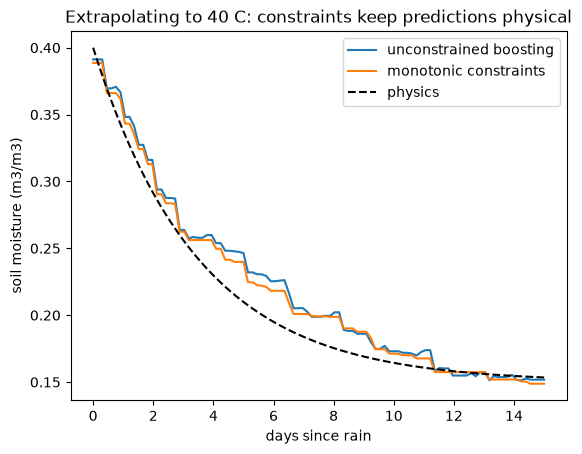

In [2]:
n = 600
temp = rng.uniform(15, 32, n); days_since_rain = rng.uniform(0, 15, n)
sm = 0.15 + 0.25 * np.exp(-days_since_rain / (6 - 0.1 * (temp - 15))) + rng.normal(0, 0.02, n)       # wetter right after rain, faster drying when hot
X = np.c_[temp, days_since_rain]
grid_hot = np.c_[np.full(100, 40.0), np.linspace(0, 15, 100)]                                         # 40 C: hotter than any training data
plain = HistGradientBoostingRegressor(random_state=0).fit(X, sm)
mono = HistGradientBoostingRegressor(monotonic_cst=[-1, -1], random_state=0).fit(X, sm)           # moisture must not increase with temp or dry days
plt.plot(grid_hot[:, 1], plain.predict(grid_hot), label="unconstrained boosting"); plt.plot(grid_hot[:, 1], mono.predict(grid_hot), label="monotonic constraints")
truth_hot = 0.15 + 0.25 * np.exp(-grid_hot[:, 1] / (6 - 0.1 * 25)); plt.plot(grid_hot[:, 1], truth_hot, "k--", label="physics")
plt.xlabel("days since rain"); plt.ylabel("soil moisture (m3/m3)"); plt.legend(); plt.title("Extrapolating to 40 C: constraints keep predictions physical"); plt.show()

## **3. Hybrid Modelling: ML Learns What Physics Misses**
A simple **process model** of crop yield (light-use efficiency: yield proportional to the sum of absorbed radiation, estimated from NDVI) captures the main signal but misses water stress and management. Train ML on the **residuals** of the process model. The hybrid needs less data and extrapolates the physical part correctly.

In [3]:
def make_fields(n, seed, ndvi_range=(0.3, 0.8)):
    r = np.random.default_rng(seed)
    ndvi = r.uniform(*ndvi_range, n); par = r.uniform(900, 1300, n); water = r.uniform(0.3, 1.0, n); nitrogen = r.uniform(0, 1, n)
    apar = (1.25 * ndvi - 0.15) * par                                                     # absorbed PAR via fAPAR ~ linear in NDVI
    yield_ = 0.006 * apar * (0.6 + 0.4 * water) * (0.8 + 0.2 * nitrogen) + r.normal(0, 0.25, n)
    return pd.DataFrame({"ndvi": ndvi, "par": par, "water_index": water, "nitrogen": nitrogen, "apar": apar, "yield": yield_})
train = make_fields(150, 1); test_in = make_fields(1000, 2); test_out = make_fields(1000, 3, ndvi_range=(0.8, 0.95))   # out-of-range NDVI
feat = ["ndvi", "par", "water_index", "nitrogen"]

lue = (train["yield"] / train.apar).median()                                            # calibrate the light-use efficiency from data
proc = lambda d: lue * d.apar
rf = RandomForestRegressor(500, min_samples_leaf=3, random_state=0).fit(train[feat], train["yield"])
hyb = RandomForestRegressor(500, min_samples_leaf=3, random_state=0).fit(train[feat], train["yield"] / proc(train))    # ML learns a multiplicative correction
rmse = lambda a, b: np.sqrt(np.mean((a - b) ** 2))
rows = {}
for name, d in [("in-range test", test_in), ("NDVI beyond training range", test_out)]:
    rows[name] = {"process model only": rmse(d["yield"], proc(d)), "Random Forest only": rmse(d["yield"], rf.predict(d[feat])),
                  "hybrid (process x RF correction)": rmse(d["yield"], proc(d) * hyb.predict(d[feat]))}
pd.DataFrame(rows).round(3).rename_axis("RMSE (t/ha)")

,in-range test,NDVI beyond training range
RMSE (t/ha),,
process model only,0.423,0.621
Random Forest only,0.400,1.139
hybrid (process x RF correction),0.271,0.302


The RF alone cannot extrapolate to higher NDVI (trees predict the last leaf); the hybrid inherits the physically correct linear growth from the process model and learns only the correction.

## **4. Physics-Informed Neural Networks (PINNs)**
Raissi et al. (2019): a network $u_\theta(t)$ approximates the solution of a differential equation. The loss combines (1) misfit to the few available observations and (2) the **residual of the equation** at many collocation points, computed with autograd (Day 8, 59):
$$\mathcal L = \frac{1}{N_d}\sum\big(u_\theta(t_i) - u_i\big)^2 + \lambda\frac{1}{N_c}\sum\big(\mathcal N[u_\theta](t_j)\big)^2$$

Example: **groundwater / reservoir drawdown** or **soil-water drydown** obeys $\frac{du}{dt} = -k\,u + s(t)$ (exponential decay with a source term). We observe only 6 noisy points in the first 3 days and want the curve over 15 days.

trained in 10s


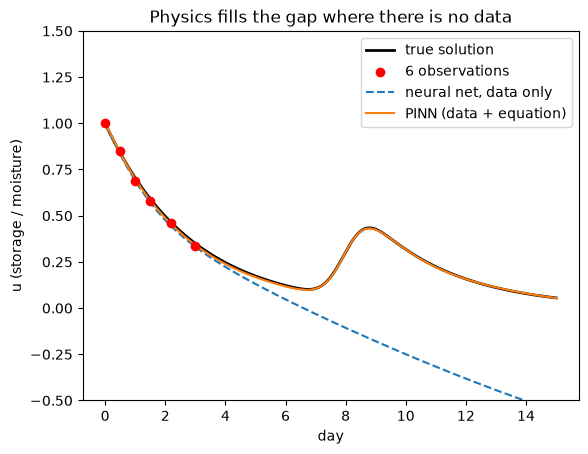

RMSE over 15 days: data-only NN 0.392 | PINN 0.005


In [4]:
k_true = 0.35
def source(t): return 0.4 * torch.exp(-((t - 8) / 0.8) ** 2)                            # a rain pulse on day 8 (known forcing)
t_fine = np.linspace(0, 15, 3001); u = np.zeros_like(t_fine); u[0] = 1.0; dt = t_fine[1] - t_fine[0]
for i in range(1, len(t_fine)):                                                          # reference solution (Euler, fine step)
    u[i] = u[i - 1] + dt * (-k_true * u[i - 1] + 0.4 * np.exp(-((t_fine[i - 1] - 8) / 0.8) ** 2))
obs_t = np.array([0.0, 0.5, 1.0, 1.5, 2.2, 3.0]); obs_u = np.interp(obs_t, t_fine, u) + rng.normal(0, 0.01, len(obs_t))

class PINN(nn.Module):
    def __init__(self, h=48):
        super().__init__(); self.net = nn.Sequential(nn.Linear(1, h), nn.Tanh(), nn.Linear(h, h), nn.Tanh(), nn.Linear(h, h), nn.Tanh(), nn.Linear(h, 1))
    def forward(self, t): return self.net(t / 15.0)                                       # scale input

def train_pinn(use_physics=True, learn_k=False, steps=5000, lam=1.0, seed=0):
    torch.manual_seed(seed); m = PINN(); log_k = nn.Parameter(torch.tensor(np.log(0.1), dtype=torch.float32))
    params = list(m.parameters()) + ([log_k] if learn_k else []); opt = torch.optim.Adam(params, 3e-3)
    to, uo = torch.tensor(obs_t[:, None], dtype=torch.float32), torch.tensor(obs_u[:, None], dtype=torch.float32)
    tc = torch.linspace(0, 15, 300)[:, None].requires_grad_(True)
    for s in range(steps):
        loss = F.mse_loss(m(to), uo)
        if use_physics:
            uc = m(tc); du = torch.autograd.grad(uc.sum(), tc, create_graph=True)[0]
            k = torch.exp(log_k) if learn_k else k_true
            loss = loss + lam * ((du + k * uc - source(tc)) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return m, torch.exp(log_k).item() if learn_k else k_true

t0 = time.perf_counter()
nn_only, _ = train_pinn(use_physics=False, steps=3000); pinn, _ = train_pinn(use_physics=True)
tg = torch.tensor(t_fine[::10, None], dtype=torch.float32)
with torch.no_grad(): u_nn, u_pinn = nn_only(tg).numpy().ravel(), pinn(tg).numpy().ravel()
print(f"trained in {time.perf_counter() - t0:.0f}s")
plt.plot(t_fine, u, "k", lw=2, label="true solution"); plt.scatter(obs_t, obs_u, c="r", zorder=3, label="6 observations")
plt.plot(t_fine[::10], u_nn, "--", label="neural net, data only"); plt.plot(t_fine[::10], u_pinn, label="PINN (data + equation)")
plt.ylim(-0.5, 1.5); plt.xlabel("day"); plt.ylabel("u (storage / moisture)"); plt.legend(); plt.title("Physics fills the gap where there is no data"); plt.show()
print(f"RMSE over 15 days: data-only NN {np.sqrt(np.mean((u_nn - u[::10]) ** 2)):.3f} | PINN {np.sqrt(np.mean((u_pinn - u[::10]) ** 2)):.3f}")

## **5. Emulators of Physical Simulators**
Radiative transfer models (e.g. PROSAIL) map leaf and canopy traits to reflectance, but are slow to invert pixel by pixel. Train a fast **emulator** on simulator runs, or directly train the **inverse** model (reflectance -> trait) on simulated data (a hybrid retrieval scheme widely used for LAI and chlorophyll from Sentinel-2).

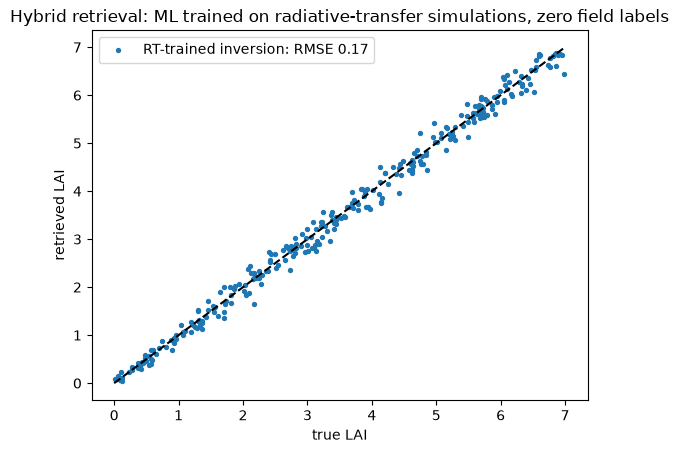

In [5]:
def toy_canopy_rt(lai, chl, soil_brightness):
    """A toy canopy reflectance model (4 bands: green, red, red-edge, NIR) with saturation in LAI (NOT PROSAIL)."""
    cover = 1 - np.exp(-0.5 * lai)
    leaf = np.stack([0.12 - 0.0008 * chl, 0.06 - 0.0006 * chl, 0.30 - 0.002 * chl, 0.48 + 0 * chl], -1)
    soil = soil_brightness[..., None] * np.array([0.12, 0.15, 0.18, 0.22])
    return (cover[..., None] * leaf * (1 + 0.05 * lai[..., None]) + (1 - cover[..., None]) * soil).clip(0.001)

N_sim = 20000
lai_s, chl_s, soil_s = rng.uniform(0, 7, N_sim), rng.uniform(10, 80, N_sim), rng.uniform(0.6, 1.4, N_sim)
R_sim = toy_canopy_rt(lai_s, chl_s, soil_s) + rng.normal(0, 0.005, (N_sim, 4))
inv = HistGradientBoostingRegressor(max_iter=400, random_state=0).fit(R_sim, lai_s)              # hybrid retrieval: learn the inverse on simulations
lai_field = rng.uniform(0, 7, 300); R_field = toy_canopy_rt(lai_field, rng.uniform(10, 80, 300), rng.uniform(0.6, 1.4, 300)) + rng.normal(0, 0.008, (300, 4))
lai_hat = inv.predict(R_field)
ndvi_field = (R_field[:, 3] - R_field[:, 1]) / (R_field[:, 3] + R_field[:, 1])
plt.scatter(lai_field, lai_hat, s=8, label=f"RT-trained inversion: RMSE {rmse(lai_field, lai_hat):.2f}"); plt.plot([0, 7], [0, 7], "k--")
plt.xlabel("true LAI"); plt.ylabel("retrieved LAI"); plt.legend(); plt.title("Hybrid retrieval: ML trained on radiative-transfer simulations, zero field labels"); plt.show()

# **Part 2: Going Deeper - Inverse Problems With PINNs**

The same PINN can **learn unknown physical parameters**: make $k$ trainable and fit it jointly with $u_\theta$. Here observations are spread over 15 days but sparse and noisy.

In [6]:
obs_t = np.sort(rng.uniform(0, 15, 15)); obs_u = np.interp(obs_t, t_fine, u) + rng.normal(0, 0.02, len(obs_t))
pinn_inv, k_hat = train_pinn(use_physics=True, learn_k=True, steps=6000)
print(f"estimated decay constant k = {k_hat:.3f} (true {k_true}) from {len(obs_t)} noisy observations")

estimated decay constant k = 0.352 (true 0.35) from 15 noisy observations


### Caveats
- PINN training can be slow and fragile (balancing loss terms, stiff equations); classical numerical solvers are better for **forward** problems with known parameters.
- The physics must be **right**: a wrong equation biases the model confidently. Validate on independent data.
- Hybrid models need careful interfaces (units, scales) and still need honest out-of-sample validation.

## **Practice Problems**
1. Train the hybrid yield model with only 30 training fields. How do RF-only and hybrid compare now?
2. Vary the physics-loss weight lambda (0.01, 1, 100) in the PINN. What happens to the fit near the observations and in the gap?
3. Retrieve **chlorophyll** instead of LAI with the RT-trained inversion. Is it harder? Why (hint: saturation and the red-edge band)?
4. *(Advanced)* Add a wrong source term to the PINN (rain pulse on day 10 instead of 8). How does the solution change? What does this say about trusting physics constraints?

In [7]:
# Solution 1
small = make_fields(30, 9)
rf_s = RandomForestRegressor(500, random_state=0).fit(small[feat], small["yield"]); hyb_s = RandomForestRegressor(500, random_state=0).fit(small[feat], small["yield"] / (lue * small.apar))
print(f"30 fields, out-of-range test RMSE: RF {rmse(test_out['yield'], rf_s.predict(test_out[feat])):.3f} | hybrid {rmse(test_out['yield'], lue * test_out.apar * hyb_s.predict(test_out[feat])):.3f}")
# Solution 3
inv_chl = HistGradientBoostingRegressor(max_iter=400, random_state=0).fit(R_sim, chl_s)
chl_field = rng.uniform(10, 80, 300); Rf2 = toy_canopy_rt(rng.uniform(0, 7, 300), chl_field, rng.uniform(0.6, 1.4, 300)) + rng.normal(0, 0.008, (300, 4))
print(f"chlorophyll retrieval RMSE {rmse(chl_field, inv_chl.predict(Rf2)):.1f} (range 10-80): weak signal when LAI is low (soil dominates)")

30 fields, out-of-range test RMSE: RF 0.936 | hybrid 0.368


chlorophyll retrieval RMSE 7.9 (range 10-80): weak signal when LAI is low (soil dominates)


## **Key References**
- Reichstein, M. et al. (2019). Deep learning and process understanding for data-driven Earth system science. *Nature*, 566, 195-204.
- Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). Physics-informed neural networks. *Journal of Computational Physics*, 378, 686-707.
- Karniadakis, G. E. et al. (2021). Physics-informed machine learning. *Nature Reviews Physics*, 3, 422-440.
- Karpatne, A. et al. (2017). Theory-guided data science: A new paradigm for scientific discovery from data. *IEEE TKDE*, 29(10), 2318-2331.
- Jacquemoud, S. et al. (2009). PROSPECT + SAIL models: A review of use for vegetation characterization. *Remote Sensing of Environment*, 113, S56-S66.
- Verrelst, J. et al. (2015). Optical remote sensing and the retrieval of terrestrial vegetation bio-geophysical properties - A review. *ISPRS Journal of Photogrammetry and Remote Sensing*, 108, 273-290.
- Kraft, B., Jung, M., Korner, M., Koirala, S., & Reichstein, M. (2022). Towards hybrid modeling of the global hydrological cycle. *Hydrology and Earth System Sciences*, 26, 1579-1614.